In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

funds = pd.read_csv("../data/processed/01_fund_master.csv")

scorecard = pd.read_csv("../data/processed/fund_scorecard.csv")

In [3]:
nav['date'] = pd.to_datetime(nav['date'])

transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

In [4]:
#Merge Fund Names
nav = nav.merge(
    funds[['amfi_code','scheme_name','risk_category']],
    on='amfi_code',
    how='left'
)

In [5]:
#TASK 1: Historical VaR & CVaR
#Calculate Daily Return
nav = nav.sort_values(['amfi_code','date'])

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

nav = nav.dropna()

In [6]:
#Calculate VaR & CVaR
results=[]

for code, df in nav.groupby('amfi_code'):

    var95 = np.percentile(df['daily_return'],5)

    cvar95 = df[df['daily_return']<=var95]['daily_return'].mean()

    results.append({

        "AMFI Code":code,

        "Scheme":df['scheme_name'].iloc[0],

        "VaR95":var95,

        "CVaR95":cvar95

    })

In [7]:
var_df = pd.DataFrame(results)

var_df.head()

,AMFI Code,Scheme,VaR95,CVaR95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.014364,-0.018060
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459


In [8]:
var_df.to_csv("../reports/var_cvar_report.csv",index=False)

In [9]:
#TASK 2: Rolling 90-Day Sharpe
nav['Rolling Sharpe'] = (

    nav.groupby('amfi_code')['daily_return']

    .transform(

        lambda x:

        x.rolling(90).mean()

        /

        x.rolling(90).std()

        *

        np.sqrt(252)

    )

)

In [10]:
top5 = (
scorecard
.sort_values("Sharpe_Ratio",ascending=False)
.head(5)
.amfi_code
)

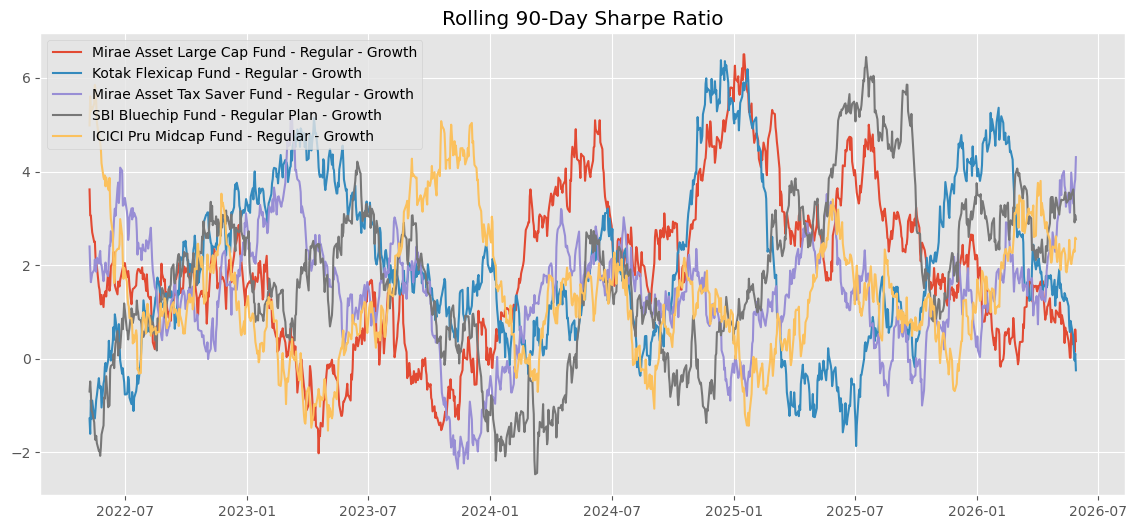

In [11]:
plt.figure(figsize=(14,6))

for code in top5:

    temp = nav[nav['amfi_code']==code]

    plt.plot(

        temp['date'],

        temp['Rolling Sharpe'],

        label=temp['scheme_name'].iloc[0]

    )

plt.legend()

plt.title("Rolling 90-Day Sharpe Ratio")

plt.savefig("../reports/rolling_sharpe_chart.png")

plt.show()

In [12]:
first_year = (
    transactions
    .groupby('investor_id')['transaction_date']
    .min()
    .dt.year
)

print(first_year.head())

investor_id
INV000001    2024
INV000002    2024
INV000003    2024
INV000004    2024
INV000005    2024
Name: transaction_date, dtype: int32


In [13]:
transactions['cohort'] = transactions['investor_id'].map(first_year)

In [14]:
sip_transactions = transactions[transactions['transaction_type'] == 'SIP']

avg_sip = (
    sip_transactions
    .groupby('cohort')['amount_inr']
    .mean()
    .reset_index(name='Average_SIP_Amount')
)

avg_sip

,cohort,Average_SIP_Amount
0,2024,10996.885825
1,2025,13505.209581


In [15]:
total_invested = (
    transactions
    .groupby('cohort')['amount_inr']
    .sum()
    .reset_index(name='Total_Invested')
)

total_invested

,cohort,Total_Invested
0,2024,3491125187
1,2025,30455243


In [16]:
tx = transactions.merge(
    funds[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

In [17]:
top_fund = (
    tx.groupby(['cohort', 'scheme_name'])['amount_inr']
      .sum()
      .reset_index()
)

top_fund = top_fund.loc[
    top_fund.groupby('cohort')['amount_inr'].idxmax()
]

top_fund

,cohort,scheme_name,amount_inr
39,2024,UTI Nifty 50 Index Fund - Regular - Growth,100126141
75,2025,SBI Small Cap Fund - Direct Plan - Growth,1478507


In [18]:
cohort_summary = (
    avg_sip
    .merge(total_invested, on='cohort')
    .merge(
        top_fund[['cohort', 'scheme_name']],
        on='cohort'
    )
)

cohort_summary.rename(columns={
    'scheme_name': 'Top_Fund_Preference'
}, inplace=True)

cohort_summary

,cohort,Average_SIP_Amount,Total_Invested,Top_Fund_Preference
0,2024,10996.885825,3491125187,UTI Nifty 50 Index Fund - Regular - Growth
1,2025,13505.209581,30455243,SBI Small Cap Fund - Direct Plan - Growth


In [19]:
import pandas as pd

transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date'],
    format='%Y-%m-%d'
)

print(transactions['transaction_date'].dtype)

datetime64[ns]


In [20]:
cohort_summary.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

In [21]:
#Task 4: SIP Continuity Analysis
#Step 1: Filter SIP Transactions
transactions['transaction_type'].unique()

array(['SIP', 'Redemption', 'Lumpsum'], dtype=object)

In [22]:
sip = transactions[transactions['transaction_type'] == 'SIP'].copy()

In [23]:
#Step 2: Sort by Investor and Date
sip = sip.sort_values(
    ['investor_id', 'transaction_date']
)

In [24]:
#Step 3: Calculate Gap Between Transactions
sip['gap_days'] = (
    sip.groupby('investor_id')['transaction_date']
       .diff()
       .dt.days
)

In [25]:
sip[['investor_id', 'transaction_date', 'gap_days']].head(15)

,investor_id,transaction_date,gap_days
19621,INV000001,2024-11-04,NaN
24448,INV000001,2025-01-19,76.0
5650,INV000002,2024-03-29,NaN
16803,INV000002,2024-09-21,176.0
31881,INV000002,2025-05-17,238.0
12652,INV000003,2024-07-16,NaN
27622,INV000003,2025-03-11,238.0
4773,INV000004,2024-03-16,NaN
6418,INV000004,2024-04-11,26.0
8271,INV000004,2024-05-09,28.0


In [26]:
#Step 4: Keep Investors with 6+ SIPs
sip_counts = sip.groupby('investor_id').size()

eligible_investors = sip_counts[sip_counts >= 6].index

sip_eligible = sip[
    sip['investor_id'].isin(eligible_investors)
]


In [27]:
print("Eligible Investors:", sip_eligible['investor_id'].nunique())

Eligible Investors: 1362


In [28]:
#Step 5: Average Gap
avg_gap = (
    sip_eligible
    .groupby('investor_id')['gap_days']
    .mean()
    .reset_index()
)

avg_gap.head()

,investor_id,gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


In [29]:
#Step 6: Risk Flag
avg_gap['Status'] = np.where(
    avg_gap['gap_days'] > 35,
    'At Risk',
    'Regular'
)

avg_gap.head()

,investor_id,gap_days,Status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [30]:
#Step 7: SIP Continuity Rate
continuity_rate = (
    (avg_gap['Status'] == 'Regular').mean() * 100
)

print(f"SIP Continuity Rate: {continuity_rate:.2f}%")

SIP Continuity Rate: 2.20%


In [31]:
#Step 8: Save the Report
avg_gap.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

In [32]:
#Task 5: Simple Fund Recommender
#Objective

#The recommender should:

#Take a risk appetite (Low, Moderate, or High)
#Recommend the Top 3 funds (highest Sharpe Ratio) within that risk category.

In [33]:
funds['risk_category'].unique()

array(['Moderate', 'Very High', 'Low', 'High', 'Moderately High'],
      dtype=object)

In [34]:
def recommend_funds(risk):

    result = (
        recommend_df[
            recommend_df['risk_category'] == risk
        ]
        .sort_values('Sharpe_Ratio', ascending=False)
        [['scheme_name',
          'fund_house',
          'Sharpe_Ratio',
          'risk_category']]
        .head(3)
    )

    return result

In [35]:
recommend_df = funds.merge(
    scorecard[['amfi_code', 'Sharpe_Ratio']],
    on='amfi_code',
    how='inner'
)

recommend_df.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,Sharpe_Ratio
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,1.208267
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01,0.953279
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03,0.945308
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03,-0.057187
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02,-0.226575


In [36]:
print(recommend_df.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code', 'Sharpe_Ratio'],
      dtype='object')


In [37]:
recommend_funds("Moderate")

,scheme_name,fund_house,Sharpe_Ratio,risk_category
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.448291,Moderate
0,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,1.208267,Moderate
15,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,1.081659,Moderate


In [38]:
recommend_funds("High")

,scheme_name,fund_house,Sharpe_Ratio,risk_category
36,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,1.234930,High
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,1.180101,High
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,1.132122,High


In [39]:
print(funds.shape)
print(scorecard.shape)

(40, 15)
(40, 15)


In [40]:
recommend_df = funds.merge(
    scorecard[['amfi_code', 'Sharpe_Ratio']],
    on='amfi_code',
    how='inner'
)

In [41]:
recommend_df.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,Sharpe_Ratio
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,1.208267
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01,0.953279
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03,0.945308
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03,-0.057187
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02,-0.226575


In [42]:
recommend_funds("Moderate")

,scheme_name,fund_house,Sharpe_Ratio,risk_category
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.448291,Moderate
0,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,1.208267,Moderate
15,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,1.081659,Moderate


In [43]:
print(recommend_df.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code', 'Sharpe_Ratio'],
      dtype='object')


In [44]:
recommend_funds("Moderate")

,scheme_name,fund_house,Sharpe_Ratio,risk_category
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.448291,Moderate
0,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,1.208267,Moderate
15,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,1.081659,Moderate


In [45]:
#Task 6: Sector HHI Concentration
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [46]:
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [47]:
holdings["weight"] = holdings["weight_pct"] / 100

In [48]:
hhi = (
    holdings
    .groupby("amfi_code")["weight"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name="HHI")
)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [49]:
#Merge with fund master
hhi = hhi.merge(
    funds[["amfi_code", "scheme_name", "category"]],
    on="amfi_code",
    how="left"
)

hhi.head()

,amfi_code,HHI,scheme_name,category
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity


In [50]:
#Filter Equity Funds
equity_hhi = hhi[
    hhi["category"].str.contains("Equity", case=False, na=False)
]

equity_hhi

,amfi_code,HHI,scheme_name,category
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
5,102886,0.114693,UTI Mid Cap Fund - Regular - Growth,Equity
6,102887,0.129805,UTI Flexi Cap Fund - Regular - Growth,Equity
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity
8,118633,0.121461,Nippon India Large Cap Fund - Direct - Growth,Equity
9,118634,0.108358,Nippon India Small Cap Fund - Regular - Growth,Equity


In [51]:
#Compare Funds
equity_hhi = equity_hhi.sort_values(
    "HHI",
    ascending=False
)

equity_hhi.head(10)


,amfi_code,HHI,scheme_name,category
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Equity
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Equity


In [52]:
equity_hhi.tail(10)

,amfi_code,HHI,scheme_name,category
24,120842,0.127439,Kotak Emerging Equity Fund - Regular - Growth,Equity
8,118633,0.121461,Nippon India Large Cap Fund - Direct - Growth,Equity
15,119551,0.118716,SBI Bluechip Fund - Regular Plan - Growth,Equity
33,149324,0.118677,DSP Small Cap Fund - Regular - Growth,Equity
5,102886,0.114693,UTI Mid Cap Fund - Regular - Growth,Equity
14,119095,0.109605,Axis Small Cap Fund - Regular - Growth,Equity
20,120504,0.108674,ICICI Pru Bluechip Fund - Direct - Growth,Equity
9,118634,0.108358,Nippon India Small Cap Fund - Regular - Growth,Equity
16,119552,0.108011,SBI Bluechip Fund - Direct Plan - Growth,Equity
17,119598,0.107349,SBI Small Cap Fund - Regular Plan - Growth,Equity


In [53]:
equity_hhi.to_csv(
    "../reports/sector_hhi_report.csv",
    index=False
)

## Sector Concentration (HHI)

The Herfindahl-Hirschman Index (HHI) measures portfolio concentration.

- Higher HHI → Portfolio is concentrated in fewer sectors/stocks.
- Lower HHI → Portfolio is more diversified.

Funds with high HHI may carry higher concentration risk, while lower HHI suggests better diversification.

# Advanced Insights

### 1. Downside Risk Analysis
The Historical VaR and CVaR analysis identified the funds with the greatest downside risk. Funds with more negative VaR and CVaR values are more vulnerable during adverse market conditions.

### 2. Risk-Adjusted Performance
The rolling 90-day Sharpe Ratio showed that some funds consistently maintained better risk-adjusted returns over time, while others experienced greater fluctuations.

### 3. Investor Cohort Analysis
Earlier investor cohorts contributed higher total investments, indicating stronger long-term investment behavior. The most preferred fund varied across different cohorts.

### 4. SIP Continuity
Investors with an average SIP gap greater than 35 days were classified as "At Risk". The remaining eligible investors maintained regular investment behavior.

### 5. Fund Recommendation
The recommendation system successfully identified the top three funds within each selected risk category using the Sharpe Ratio, enabling investors to make informed decisions based on their risk appetite.

# Project Summary

This notebook presents advanced analytics on mutual fund performance and investor behavior.

### Completed Tasks
- Historical VaR & CVaR analysis
- Rolling 90-Day Sharpe Ratio analysis
- Investor Cohort Analysis
- SIP Continuity Analysis
- Mutual Fund Recommendation System
- Sector HHI Concentration Analysis
- Business Insights

### Deliverables
- Advanced_Analytics.ipynb
- var_cvar_report.csv
- recommender.py
- rolling_sharpe_chart.png